In [90]:
import math
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

class Value:
  def __init__(self, data, _children=(), _op='', label=''): 
    self.data = data
    self._prev = set(_children)
    self._op = _op
    self.label = label
    self.grad = 0.0
    self._backward = lambda: None

  def __repr__(self):
    return f"Value({self.data}, {self._op}, {self.label}, {self.grad})"

  def __add__(self, other):
    other = other if isinstance(other, Value) else Value(other)
    out = Value(self.data + other.data, _children=(self, other), _op="+")

    def _backward():
      self.grad += out.grad
      other.grad += out.grad
    out._backward = _backward
    
    return out 
  
  def __radd__(self, other): # other + self
    return self + other
  
  def __sub__(self, other): # self - other
    return self + (-other)

  def __mul__(self, other):
    other = other if isinstance(other, Value) else Value(other)
    out =  Value(self.data * other.data, _children=(self, other), _op="*")

    def _backward():
      self.grad += other.data * out.grad
      other.grad += self.data * out.grad
    out._backward = _backward

    return out
  
  def __pow__(self, other):
    assert isinstance(other, (int, float)), "only supporting int/float powers for now"
    out = Value(self.data**other, (self,), f'**{other}')
    
    def _backward():
        self.grad += other * (self.data ** (other - 1)) * out.grad
    out._backward = _backward

    return out
  
  def tanh(self):
    x = self.data
    t = (math.exp(2*x) - 1)/(math.exp(2*x) + 1)
    out = Value(t, (self, ), 'tanh')
    
    def _backward():
      self.grad += (1 - t**2) * out.grad
    out._backward = _backward
    
    return out
  
  def exp(self):
    x = self.data
    out = Value(math.exp(x), (self, ), 'exp')
    
    def _backward():
      self.grad += out.data * out.grad
    out._backward = _backward
    
    return out
  
  def backward(self):
    topo = []
    visited = set()
    def build_topo(v):
      if v not in visited:
        visited.add(v)
        for child in v._prev:
          build_topo(child)
        topo.append(v)
    
    build_topo(self)

    self.grad = 1.0
    for n in reversed(topo):
      n._backward()
  
a = Value(2.0, label='a')
b = Value(-3.0, label='b')
c = Value(10.0, label='c')
e = a*b; e.label = 'e'
d = e + c; d.label = 'd'
f = Value(-2.0, label='f')
L = d * f; L.label = 'L'
L


Value(-8.0, *, L, 0.0)

In [41]:
import networkx as nx
import matplotlib.pyplot as plt

def trace(root):
    nodes, edges = set(), set()
    def build(v):
        if v not in nodes:
            nodes.add(v)
            for child in v._prev:
                edges.add((child, v))
                build(child)
    build(root)
    return nodes, edges

def draw_dot(root):
    nodes, edges = trace(root)
    
    G = nx.DiGraph()
    
    for n in nodes:
        G.add_node(id(n), label=f"{n.label}\ndata: {n.data:.4f}\ngrad: {n.grad:.4f}")
        if n._op:
            op_id = id(n) + 1
            G.add_node(op_id, label=n._op)
            G.add_edge(op_id, id(n))
    
    for n1, n2 in edges:
        G.add_edge(id(n1), id(n2) + 1)
    
    plt.figure(figsize=(12, 8))
    pos = nx.spring_layout(G)
    nx.draw(G, pos, with_labels=False, node_color='lightblue', 
            node_size=4000, arrows=True)
    
    labels = nx.get_node_attributes(G, 'label')
    nx.draw_networkx_labels(G, pos, labels, font_size=8)
    
    plt.axis('off')
    plt.tight_layout()
    plt.show()


/var/folders/7v/z307z80n60sbzprkynb7wblm0000gn/T/ipykernel_36520/4258734158.py:39: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


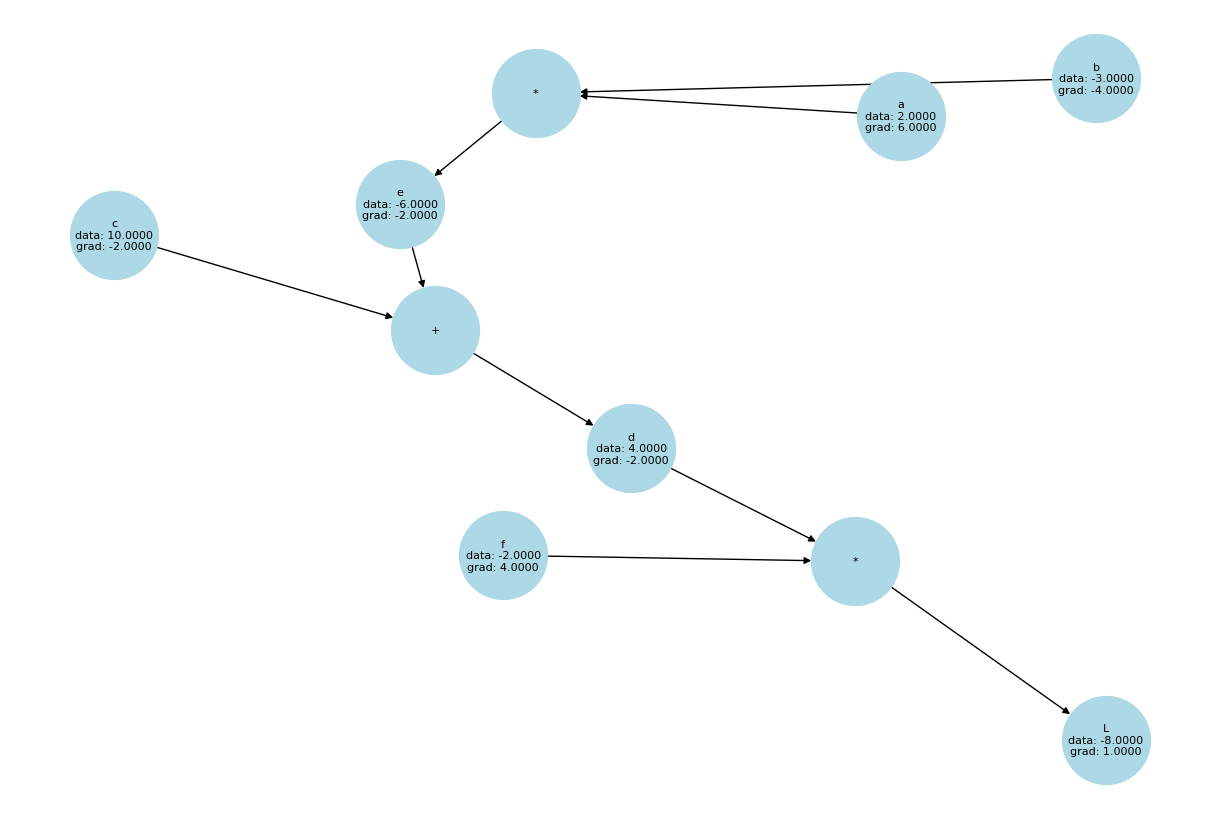

In [42]:
draw_dot(L)

In [89]:
def lol():
  
  h = 0.001
  
  a = Value(2.0, label='a')
  b = Value(-3.0, label='b')
  c = Value(10.0, label='c')
  e = a*b; e.label = 'e'
  d = e + c; d.label = 'd'
  f = Value(-2.0, label='f')
  L = d * f; L.label = 'L'
  L1 = L.data
  
  a = Value(2.0, label='a')
  b = Value(-3.0, label='b')
  b.data += h
  c = Value(10.0, label='c')
  e = a*b; e.label = 'e'
  d = e + c; d.label = 'd'
  f = Value(-2.0, label='f')
  L = d * f; L.label = 'L'
  L2 = L.data
  
  print((L2 - L1)/h)
  
lol()

-3.9999999999995595


In [95]:
a.data += 0.01 * a.grad
print(a)
b.data += 0.01 * b.grad
c.data += 0.01 * c.grad
f.data += 0.01 * f.grad

e = a * b
d = e + c
L = d * f

print(L.data)

Value(2.06, , a, 6.0)
-7.286496


In [94]:
L.backward()

In [132]:
# inputs x1,x2
x1 = Value(2.0, label='x1')
x2 = Value(0.0, label='x2')
# weights w1,w2
w1 = Value(-3.0, label='w1')
w2 = Value(1.0, label='w2')
# bias of the neuron
b = Value(6.8813735870195432, label='b')
# x1*w1 + x2*w2 + b
x1w1 = x1*w1; x1w1.label = 'x1*w1'
x2w2 = x2*w2; x2w2.label = 'x2*w2'
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = 'x1*w1 + x2*w2'
n = x1w1x2w2 + b; n.label = 'n'
e = (n*2).exp()
o = (e - 1) / (e + 1) 
o.label = 'o'
o.backward()
draw_dot(o)

TypeError: unsupported operand type(s) for /: 'Value' and 'Value'

/var/folders/7v/z307z80n60sbzprkynb7wblm0000gn/T/ipykernel_36520/4258734158.py:39: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


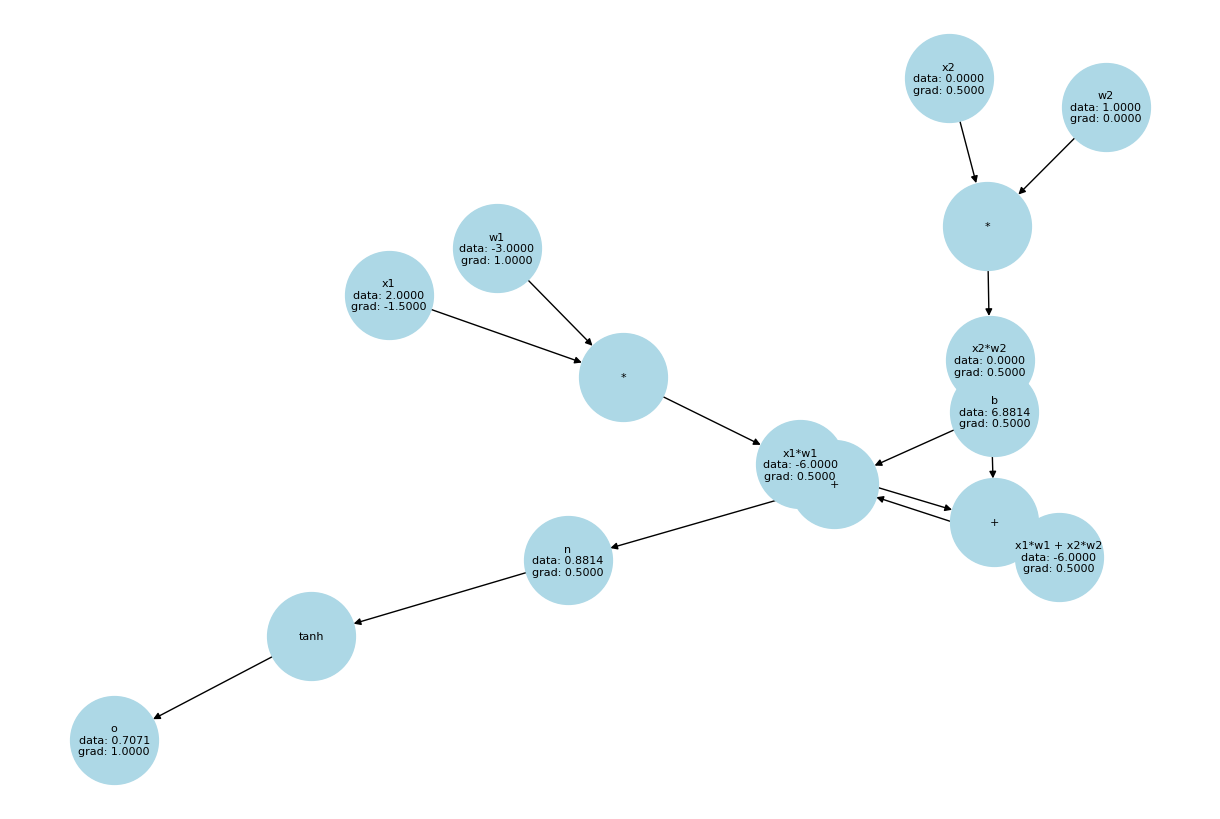

In [112]:
import random
class Neuron:
  
  def __init__(self, nin):
    self.w = [Value(random.uniform(-1,1)) for _ in range(nin)]
    self.b = Value(random.uniform(-1,1))
  
  def __call__(self, x):
    # w * x + b
    act = sum((wi*xi for wi, xi in zip(self.w, x)), self.b)
    out = act.tanh()
    return out
  
  def parameters(self):
    return self.w + [self.b]

In [123]:
x = [2.0, 3.0]
n = Neuron(2)
n(x)


Value(0.1339664292418024, tanh, , 0.0)

In [124]:
class Layer:
  def __init__(self, nin, nout):
    self.neurons = [Neuron(nin) for _ in range(nout)]

  def __call__(self, x):
    outs = [n(x) for n in self.neurons]
    return outs[0] if len(outs) == 1 else outs


  def parameters(self):
    return [p for neuron in self.neurons for p in neuron.parameters()]

In [131]:
x = [2.0, 3.0]
n = Layer(2, 3)
n(x)

[Value(0.9700061380252863, tanh, , 0.0),
 Value(-0.19141971428702637, tanh, , 0.0),
 Value(-0.5006459613490446, tanh, , 0.0)]

In [127]:
class MLP:
  def __init__(self, nin, nouts):
    sizes = [nin] + nouts
    self.layers = [Layer(sizes[i], sizes[i+1]) for i in range(len(nouts))]

  def __call__(self, x):
    for layer in self.layers:
      x = layer(x)
    return x
  
  def parameters(self):
    return [p for layer in self.layers for p in layer.parameters()]

In [135]:
x = [2.0, 3.0, -1.0]
n = MLP(3, [4, 4, 1])
n(x)

Value(0.694354703578299, tanh, , 0.0)

In [136]:
xs = [
  [2.0, 3.0, -1.0],
  [3.0, -1.0, 0.5],
  [0.5, 1.0, 1.0],
  [1.0, 1.0, -1.0],
]
ys = [1.0, -1.0, -1.0, 1.0] # desired targets
ypred = [n(x) for x in xs]
ypred

[Value(0.694354703578299, tanh, , 0.0),
 Value(0.5444382874079762, tanh, , 0.0),
 Value(-0.4908637327035004, tanh, , 0.0),
 Value(0.8357455294083844, tanh, , 0.0)]

In [137]:
n = MLP(3, [4, 4, 1])
for k in range(20):
  
  # forward pass
  ypred = [n(x) for x in xs]
  loss = sum((yout - ygt)**2 for ygt, yout in zip(ys, ypred))
  
  # backward pass
  for p in n.parameters():
    p.grad = 0.0
  loss.backward()
  
  # update
  for p in n.parameters():
    p.data += -0.05 * p.grad
  
  print(k, loss.data)

0 7.660791829935634
1 7.499139143459298
2 7.12366193541982
3 6.108492414831817
4 4.292232823536894
5 3.757919317461835
6 3.4665557216444567
7 2.723148022001703
8 0.8894278640009721
9 0.20594846061290423
10 0.14174944485653365
11 0.11241456585180969
12 0.09434896482061313
13 0.08159678785799993
14 0.0719223241120493
15 0.06426171003976273
16 0.05802147750154153
17 0.0528330847202615
18 0.048450397555439825
19 0.04470049372930894


In [84]:
ypred

[Value(-0.998276588069285, tanh, , -3.99655317613857),
 Value(-0.9982750290185064, tanh, , 0.003449941962987202),
 Value(-0.9982721874467705, tanh, , 0.003455625106459026),
 Value(-0.9982669055487667, tanh, , -3.9965338110975335)]